In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# New Section

In [11]:
df= pd.read_csv('/content/drive/MyDrive/cars_data.csv')

In [13]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [12]:
display(df.head())

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [25]:
display(df.tail())

,Make,Model,Year,HP,Total Cylinders,Mechanism,Drive Mode,MPG-H,MPG-C,Price
11909,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,46120
11910,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,56670
11911,Acura,ZDX,2012,300.0,6.0,AUTOMATIC,all wheel drive,23,16,50620
11912,Acura,ZDX,2013,300.0,6.0,AUTOMATIC,all wheel drive,23,16,50920
11913,Lincoln,Zephyr,2006,221.0,6.0,AUTOMATIC,front wheel drive,26,17,28995


In [27]:
df.dtypes

,0
Make,object
Model,object
Year,int64
HP,float64
Total Cylinders,float64
Mechanism,object
Drive Mode,object
MPG-H,int64
MPG-C,int64
Price,int64


In [15]:
df=df.drop(['Engine Fuel Type','Market Category','Vehicle Style','Popularity','Number of Doors','Vehicle Size'], axis=1)
df.head(5)

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [17]:
df= df.rename(columns={"Engine HP": "HP", "Engine Cylinders": "Total Cylinders", "Transmission Type": "Mechanism", "Driven_Wheels": "Drive Mode","highway MPG": "MPG-H", "city mpg": "MPG-C", "MSRP": "Price"} )
df.head(5)

,Make,Model,Year,HP,Total Cylinders,Mechanism,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [18]:
df.shape

(11914, 10)

In [19]:
df.count()

,0
Make,11914
Model,11914
Year,11914
HP,11845
Total Cylinders,11884
Mechanism,11914
Drive Mode,11914
MPG-H,11914
MPG-C,11914
Price,11914


In [20]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (989, 10)


In [21]:
df= df.drop_duplicates()
df.head(5)

,Make,Model,Year,HP,Total Cylinders,Mechanism,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


In [22]:
print(df.isnull().sum())

Make                0
Model               0
Year                0
HP                 69
Total Cylinders    30
Mechanism           0
Drive Mode          0
MPG-H               0
MPG-C               0
Price               0
dtype: int64


In [24]:
df= df.dropna()
df.count()

,0
Make,10827
Model,10827
Year,10827
HP,10827
Total Cylinders,10827
Mechanism,10827
Drive Mode,10827
MPG-H,10827
MPG-C,10827
Price,10827


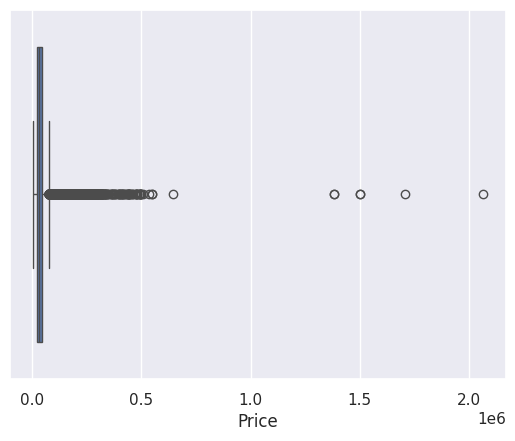

In [29]:
sns.boxplot(x= df['Price'])
plt.show()

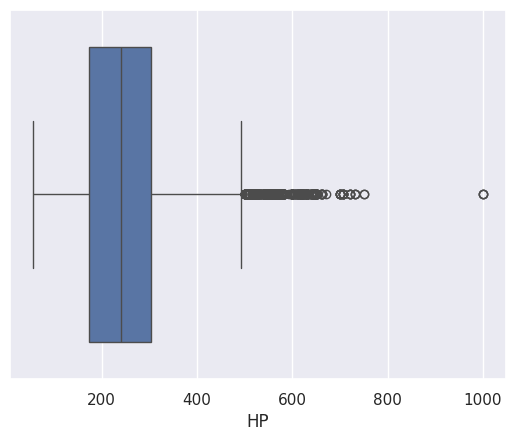

In [30]:
sns.boxplot(x=df['HP'])
plt.show()

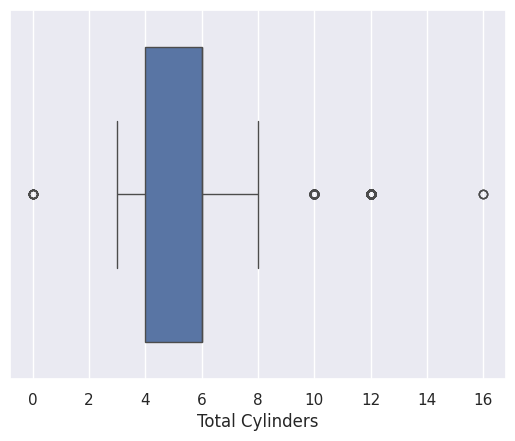

In [31]:
sns.boxplot(x=df['Total Cylinders'])
plt.show()

In [32]:
numeric_cols = df.select_dtypes(include='number').columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_cleaned= df[condition]
print(df_cleaned.shape)

(9191, 10)


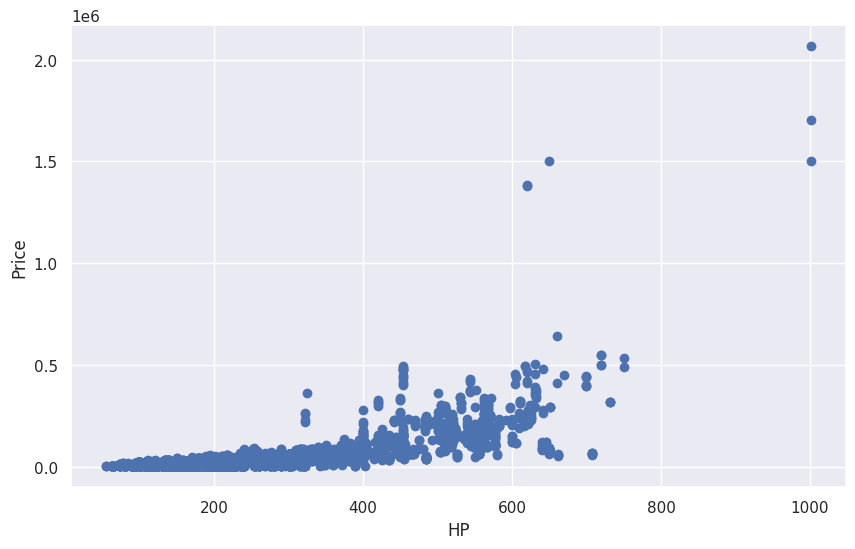

In [33]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['HP'], df['Price'])
ax.set_xlabel('HP')
ax.set_ylabel('Price')
plt.show()

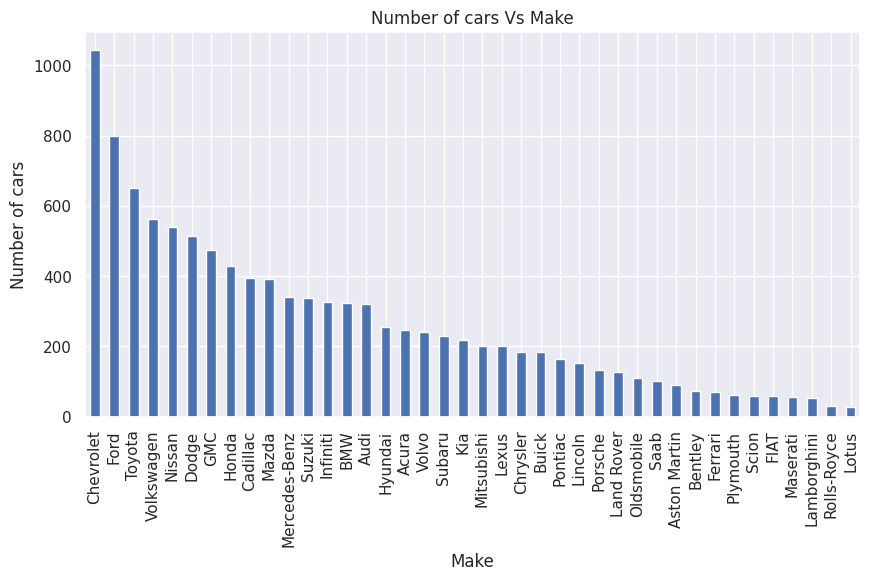

In [34]:
df.Make.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Number of cars Vs Make")
plt.ylabel('Number of cars')
plt.xlabel('Make')
plt.show()

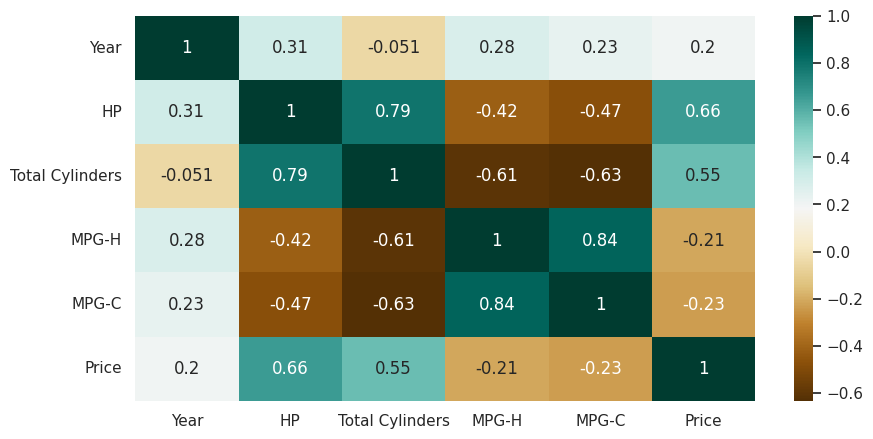

In [35]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,5))
c = numeric_df.corr()
sns.heatmap(c, cmap="BrBG", annot=True)
plt.show()